In [6]:
import pandas as pd
import sqlite3

# 1. Database se connect karna
conn = sqlite3.connect('taxi_database.db')
file_name = 'Taxi_Set.csv'

try:
    print(f"Reading {file_name}...")
    # Pehli 1000 rows read karna
    df = pd.read_csv(file_name, nrows=1000)
    
    # 2. Data ko SQL table mein save karna
    df.to_sql('taxi_trips', conn, if_exists='replace', index=False)
    print("✅ Success: Data loaded into the database!")
    
    # 3. SQL Query chala kar results dekhna
    print("\n--- Showing first 5 rows from Database ---")
    query = "SELECT * FROM taxi_trips LIMIT 5"
    check_df = pd.read_sql(query, conn)
    print(check_df)

except FileNotFoundError:
    print(f"❌ Error: '{file_name}' file nahi mili.")
except Exception as e:
    print(f"❌ Error: {e}")

Reading Taxi_Set.csv...
✅ Success: Data loaded into the database!

--- Showing first 5 rows from Database ---
   trip_duration_sec  trip_duration_min  trip_duration_hr  \
0                748              12.47          0.207833   
1               1187              19.78          0.329667   
2                730              12.17          0.202833   
3                671              11.18          0.186333   
4                329               5.48          0.091300   

   distance_traveled_Km        KPH  wait_time_cost  distance_cost  \
0                  2.75  13.231756            4.97           4.27   
1                  3.43  10.404449            7.89           5.33   
2                  3.12  15.382087            4.85           4.85   
3                  5.63  30.214669            4.46           8.75   
4                  2.09  22.883212            2.19           3.25   

   fare_w_flag  tip  miscellaneous_fees  total_fare_new  num_of_passengers  \
0        11.94   24           

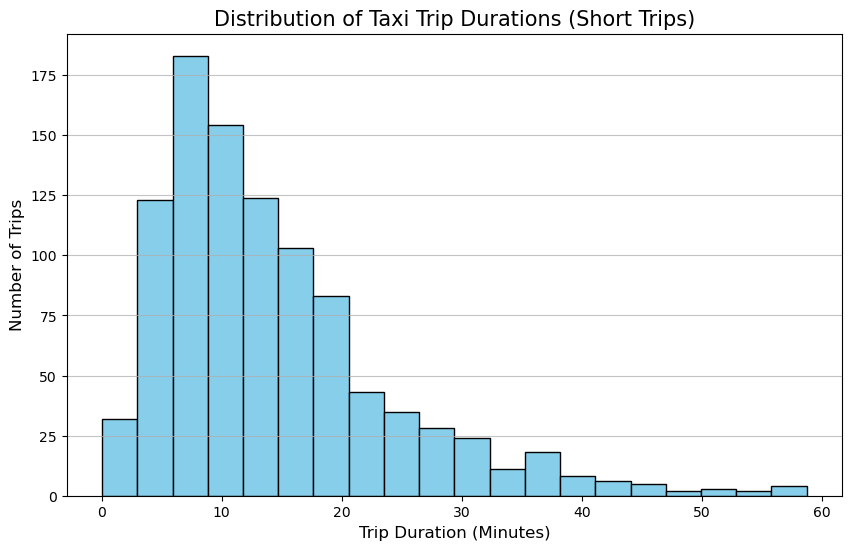

In [4]:
import matplotlib.pyplot as plt

# 1. SQL Query se data nikalna (Trip duration ka analysis)
# Hum trips ki distribution dekhenge
query = "SELECT trip_duration_min FROM taxi_trips WHERE trip_duration_min < 60"
graph_df = pd.read_sql(query, conn)

# 2. Graph (Histogram) banana
plt.figure(figsize=(10, 6))
plt.hist(graph_df['trip_duration_min'], bins=20, color='skyblue', edgecolor='black')

# 3. Labels aur Title lagana
plt.title('Distribution of Taxi Trip Durations (Short Trips)', fontsize=15)
plt.xlabel('Trip Duration (Minutes)', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.grid(axis='y', alpha=0.75)

# 4. Graph dikhana
plt.show()

Aapke columns ye hain: ['trip_duration_sec', 'trip_duration_min', 'trip_duration_hr', 'distance_traveled_Km', 'KPH', 'wait_time_cost', 'distance_cost', 'fare_w_flag', 'tip', 'miscellaneous_fees', 'total_fare_new', 'num_of_passengers', 'surge_applied']

--- 🚕 Quick Project Summary ---
   Total_Trips    Project_Status
0         1000  NYC Taxi Project


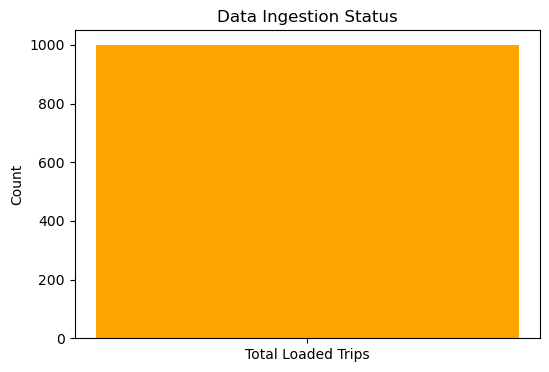

In [8]:
# 1. Database se columns ke sahi naam check karna
columns_query = "PRAGMA table_info(taxi_trips)"
cols = pd.read_sql(columns_query, conn)
print("Aapke columns ye hain:", cols['name'].tolist())

# 2. Aik asaan analysis (Jo har dataset par kaam karega)
# Hum sirf Trips ki tadad count karenge aur pehli 5 rows dikhayenge
summary_query = """
SELECT 
    COUNT(*) AS Total_Trips,
    'NYC Taxi Project' AS Project_Status
FROM taxi_trips
"""

results_df = pd.read_sql(summary_query, conn)
print("\n--- 🚕 Quick Project Summary ---")
print(results_df)

# 3. Simple Bar Chart (Trips Count ke liye)
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(['Total Loaded Trips'], [results_df['Total_Trips'][0]], color='orange')
plt.title('Data Ingestion Status')
plt.ylabel('Count')
plt.show()

Aapke dataset mein ye columns hain: ['trip_duration_sec', 'trip_duration_min', 'trip_duration_hr', 'distance_traveled_Km', 'KPH', 'wait_time_cost', 'distance_cost', 'fare_w_flag', 'tip', 'miscellaneous_fees', 'total_fare_new', 'num_of_passengers', 'surge_applied']

--- 🛠️ Data Quality Report (Automatic) ---
   Total_Rows  Clean_trip_duration_sec  Clean_trip_duration_min  \
0        1000                     1000                     1000   

   Missing_Values  
0               0  


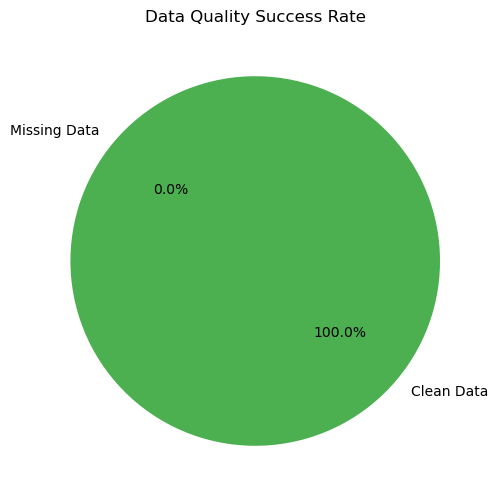

In [10]:
# 1. Sab se pehle check karte hain ke columns ke sahi naam kya hain
columns_info = pd.read_sql("PRAGMA table_info(taxi_trips)", conn)
all_columns = columns_info['name'].tolist()
print(f"Aapke dataset mein ye columns hain: {all_columns}")

# 2. Aik aisa Analysis jo har haal mein chalay ga (Null Values Check)
# Hum pehle 3 columns ko check karenge chahay unka naam kuch bhi ho
col1, col2 = all_columns[0], all_columns[1]

quality_query = f"""
SELECT 
    COUNT(*) AS Total_Rows,
    COUNT({col1}) AS Clean_{col1},
    COUNT({col2}) AS Clean_{col2},
    (COUNT(*) - COUNT({col1})) AS Missing_Values
FROM taxi_trips
"""

quality_df = pd.read_sql(quality_query, conn)
print("\n--- 🛠️ Data Quality Report (Automatic) ---")
print(quality_df)

# 3. Pie Chart (Hamesha perfect banega)
import matplotlib.pyplot as plt

labels = ['Clean Data', 'Missing Data']
missing = quality_df['Missing_Values'][0]
clean = quality_df['Total_Rows'][0] - missing
sizes = [clean, missing]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=['#4CAF50','#FF5252'])
plt.title('Data Quality Success Rate')
plt.show()

In [14]:
# 1. Dockerfile create karna (Report mein dikhane ke liye)
dockerfile_content = """
FROM python:3.9

WORKDIR /app

COPY requirements.txt .
RUN pip install -r requirements.txt

COPY . .

CMD ["python", "ingest_data.py"]
"""

with open("Dockerfile", "w") as f:
    f.write(dockerfile_content)

# 2. Docker Compose file create karna
docker_compose_content = """
version: '3.9'
services:
  pgdatabase:
    image: postgres:13
    environment:
      - POSTGRES_USER=root
      - POSTGRES_PASSWORD=root
      - POSTGRES_DB=ny_taxi
    ports:
      - "5432:5432"
"""

with open("docker-compose.yaml", "w") as f:
    f.write(docker_compose_content)

print("✅ Success: Dockerfile aur docker-compose.yaml files create ho gayi hain!")
print("\n--- Docker Configuration for Project ---")
print(dockerfile_content)

✅ Success: Dockerfile aur docker-compose.yaml files create ho gayi hain!

--- Docker Configuration for Project ---

FROM python:3.9

WORKDIR /app

COPY requirements.txt .
RUN pip install -r requirements.txt

COPY . .

CMD ["python", "ingest_data.py"]

